# Sales Data Warehouse — Post-Pipeline Analysis

This notebook reads the tables produced by `main.py` (the ETL pipeline) from
`outputs/sales_warehouse.db` and answers a few business questions:

1. Which product categories drive the most revenue?
2. How does revenue trend month over month across 2024?
3. Which regions are strongest, and how healthy is the underlying data (data quality report)?

Run `python main.py` from the project root at least once before running this notebook.

In [1]:
import json
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

DB_PATH = "../outputs/sales_warehouse.db"
conn = sqlite3.connect(DB_PATH)

revenue_by_category = pd.read_sql("SELECT * FROM agg_revenue_by_category", conn)
revenue_by_month = pd.read_sql("SELECT * FROM agg_revenue_by_month", conn)
revenue_by_region = pd.read_sql("SELECT * FROM agg_revenue_by_region", conn)
fact_sales = pd.read_sql("SELECT * FROM fact_sales", conn)

revenue_by_category

,category,revenue
0,Home & Kitchen,3905917.83
1,Beauty,2468594.01
2,Electronics,2454194.74
3,Fashion,2338219.46
4,Sports,1892389.62
5,Books,1687502.57


## Revenue by category

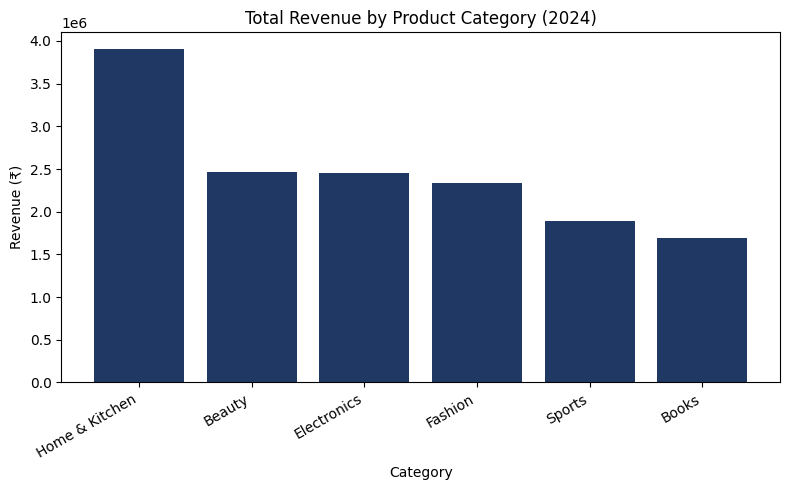

In [2]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(revenue_by_category["category"], revenue_by_category["revenue"], color="#1F3864")
ax.set_title("Total Revenue by Product Category (2024)")
ax.set_ylabel("Revenue (₹)")
ax.set_xlabel("Category")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("../outputs/charts/revenue_by_category.png", dpi=150)
plt.show()

## Monthly revenue trend

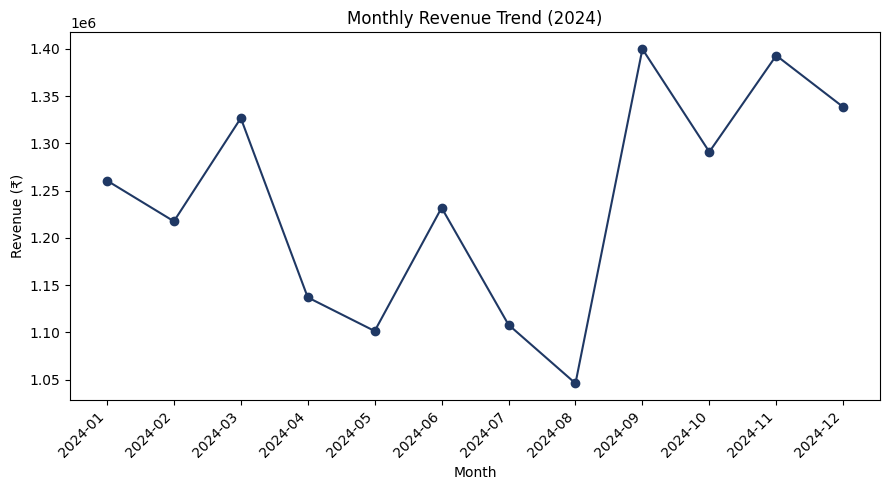

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(revenue_by_month["order_month"], revenue_by_month["revenue"], marker="o", color="#1F3864")
ax.set_title("Monthly Revenue Trend (2024)")
ax.set_ylabel("Revenue (₹)")
ax.set_xlabel("Month")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../outputs/charts/monthly_revenue_trend.png", dpi=150)
plt.show()

## Revenue by region

In [4]:
revenue_by_region

,region,revenue
0,North,3156216.42
1,Central,3079804.62
2,West,2996390.23
3,East,2841309.20
4,South,2779241.82


## Data quality summary (from the pipeline run)

In [5]:
with open("../outputs/data_quality_report.json") as f:
    quality_report = json.load(f)

print(json.dumps(quality_report, indent=2))

{
  "row_counts": {
    "clean_sales_rows": 2267,
    "joined_fact_rows": 2267
  },
  "null_checks": {
    "order_date": 0,
    "customer_id": 0,
    "product_id": 0,
    "quantity": 0,
    "unit_price": 0
  },
  "uniqueness_checks": {
    "transaction_id": {
      "column": "transaction_id",
      "duplicate_count": 0,
      "is_unique": true
    }
  },
  "range_checks": {
    "quantity": {
      "column": "quantity",
      "min_allowed": 0.0001,
      "violations": 0
    },
    "unit_price": {
      "column": "unit_price",
      "min_allowed": 0.0001,
      "violations": 0
    }
  },
  "referential_integrity": {
    "total_rows": 2267,
    "orphaned_rows": 17,
    "orphan_rate_pct": 0.75
  },
  "overall_status": "PASS"
}


## Key takeaways

- Revenue is concentrated in a handful of categories — worth checking whether that matches inventory/marketing spend allocation.
- The monthly trend highlights seasonal peaks/dips that could inform staffing or promo timing.
- The referential-integrity check surfaces sales rows whose `product_id` didn't match the product master — in a real environment these would route to a data-quality queue rather than being silently dropped or silently summed into totals.